In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/msafi04/predict-mortality-of-icu-patients-physionet/Outcomes-a.txt
/kaggle/input/datasets/msafi04/predict-mortality-of-icu-patients-physionet/set-a/set-a/137021.txt
/kaggle/input/datasets/msafi04/predict-mortality-of-icu-patients-physionet/set-a/set-a/133611.txt
/kaggle/input/datasets/msafi04/predict-mortality-of-icu-patients-physionet/set-a/set-a/137860.txt
/kaggle/input/datasets/msafi04/predict-mortality-of-icu-patients-physionet/set-a/set-a/134781.txt
/kaggle/input/datasets/msafi04/predict-mortality-of-icu-patients-physionet/set-a/set-a/133534.txt
/kaggle/input/datasets/msafi04/predict-mortality-of-icu-patients-physionet/set-a/set-a/141457.txt
/kaggle/input/datasets/msafi04/predict-mortality-of-icu-patients-physionet/set-a/set-a/135357.txt
/kaggle/input/datasets/msafi04/predict-mortality-of-icu-patients-physionet/set-a/set-a/134112.txt
/kaggle/input/datasets/msafi04/predict-mortality-of-icu-patients-physionet/set-a/set-a/133995.txt
/kaggle/input/datasets/msafi

In [11]:
import os

patient_path = '/kaggle/input/datasets/msafi04/predict-mortality-of-icu-patients-physionet/set-a/set-a/'
labels_path  = '/kaggle/input/datasets/msafi04/predict-mortality-of-icu-patients-physionet/set-a/Outcomes-a.txt'

patient_files = sorted([f for f in os.listdir(patient_path) if f.endswith('.txt')])
print(f"✅ Patient files found : {len(patient_files)}")
print(f"   Sample files        : {patient_files[:5]}")
print(f"\n✅ Labels file exists  : {os.path.exists(labels_path)}")

# Peek inside one patient file
with open(os.path.join(patient_path, patient_files[0]), 'r') as f:
    content = f.read()
print(f"\n📋 Sample patient file preview:")
print(content[:600])

✅ Patient files found : 4000
   Sample files        : ['132539.txt', '132540.txt', '132541.txt', '132543.txt', '132545.txt']

✅ Labels file exists  : False

📋 Sample patient file preview:
Time,Parameter,Value
00:00,RecordID,132539
00:00,Age,54
00:00,Gender,0
00:00,Height,-1
00:00,ICUType,4
00:00,Weight,-1
00:07,GCS,15
00:07,HR,73
00:07,NIDiasABP,65
00:07,NIMAP,92.33
00:07,NISysABP,147
00:07,RespRate,19
00:07,Temp,35.1
00:07,Urine,900
00:37,HR,77
00:37,NIDiasABP,58
00:37,NIMAP,91
00:37,NISysABP,157
00:37,RespRate,19
00:37,Temp,35.6
00:37,Urine,60
01:37,HR,60
01:37,NIDiasABP,62
01:37,NIMAP,87
01:37,NISysABP,137
01:37,RespRate,18
01:37,Urine,30
02:37,HR,62
02:37,NIDiasABP,52
02:37,NIMAP,75.67
02:37,NISysABP,123
02:37,RespRate,19
02:37,Urine,170
03:08,HCT,33.7
03:37,GCS,15
03:37,HR


In [12]:
# ============================================================
# CELL 1 — Fix labels path + Full Imports + Setup
# ============================================================
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                     Bidirectional, Masking)
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ReduceLROnPlateau,
                                        ModelCheckpoint)
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)
tf.random.set_seed(42)

# ── Find correct labels path ───────────────────────────────────
base = '/kaggle/input/datasets/msafi04/predict-mortality-of-icu-patients-physionet'
patient_path = f'{base}/set-a/set-a/'

# Search for Outcomes file anywhere
outcomes_files = glob.glob(f'{base}/**/*utcome*', recursive=True)
print("🔍 Outcomes files found:", outcomes_files)

patient_files = sorted([f for f in os.listdir(patient_path)
                         if f.endswith('.txt')])
print(f"\n✅ TensorFlow  : {tf.__version__}")
print(f"✅ Patients     : {len(patient_files)}")
print(f"✅ Setup complete!")

2026-04-11 10:51:36.320122: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775904696.785726      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775904696.895322      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775904698.028010      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775904698.028070      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775904698.028073      55 computation_placer.cc:177] computation placer alr

🔍 Outcomes files found: ['/kaggle/input/datasets/msafi04/predict-mortality-of-icu-patients-physionet/Outcomes-a.txt']

✅ TensorFlow  : 2.19.0
✅ Patients     : 4000
✅ Setup complete!


##  Section 1: Data Loading — Parsing 4000 ICU Patient Files

Each patient is stored as a separate `.txt` file with format:
`Time, Parameter, Value` — readings taken at irregular intervals over 48 hours.

We parse all files into a single structured DataFrame and merge with mortality labels.

In [13]:
# ============================================================
# CELL 2 — Parse All 4000 Patient Files + Load Labels
# ============================================================

labels_path = '/kaggle/input/datasets/msafi04/predict-mortality-of-icu-patients-physionet/Outcomes-a.txt'

# ── Load Labels ────────────────────────────────────────────────
outcomes = pd.read_csv(labels_path)
print("📋 Outcomes file preview:")
print(outcomes.head())
print(f"\nColumns: {outcomes.columns.tolist()}")
print(f"Shape  : {outcomes.shape}")
print(f"\nMortality distribution:\n{outcomes['In-hospital_death'].value_counts()}")

# ── Define vital signs we care about ──────────────────────────
VITALS = ['HR', 'NISysABP', 'NIDiasABP', 'NIMAP',
          'RespRate', 'Temp', 'GCS', 'Urine', 'SpO2', 'BUN']

# ── Parse patient files ────────────────────────────────────────
def parse_patient(filepath):
    """Parse one patient txt file → dict of vital time series"""
    df = pd.read_csv(filepath, header=0)
    df.columns = ['Time', 'Parameter', 'Value']

    # Convert time to minutes
    df['minutes'] = df['Time'].apply(
        lambda t: int(t.split(':')[0])*60 + int(t.split(':')[1]))

    # Get RecordID
    rec = df[df['Parameter'] == 'RecordID']['Value'].values
    record_id = int(rec[0]) if len(rec) > 0 else -1

    # Keep only vitals, remove negatives (missing coded as -1)
    df = df[df['Parameter'].isin(VITALS)]
    df = df[df['Value'] > 0]

    return record_id, df

# ── Parse all files (this takes ~1-2 mins) ────────────────────
print("\n⏳ Parsing 4000 patient files...")
all_records = {}
failed = 0

for i, fname in enumerate(patient_files):
    fpath = os.path.join(patient_path, fname)
    try:
        rid, df = parse_patient(fpath)
        all_records[rid] = df
    except:
        failed += 1
    if (i+1) % 500 == 0:
        print(f"   Parsed {i+1}/4000 files...")

print(f"\n✅ Successfully parsed : {len(all_records)} patients")
print(f"   Failed             : {failed}")

# ── Quick peek at one patient ──────────────────────────────────
sample_id = list(all_records.keys())[0]
print(f"\n📋 Sample patient (ID: {sample_id}):")
print(all_records[sample_id].head(10))
print(f"   Vitals available: {all_records[sample_id]['Parameter'].unique()}")

📋 Outcomes file preview:
   RecordID  SAPS-I  SOFA  Length_of_stay  Survival  In-hospital_death
0    132539       6     1               5        -1                  0
1    132540      16     8               8        -1                  0
2    132541      21    11              19        -1                  0
3    132543       7     1               9       575                  0
4    132545      17     2               4       918                  0

Columns: ['RecordID', 'SAPS-I', 'SOFA', 'Length_of_stay', 'Survival', 'In-hospital_death']
Shape  : (4000, 6)

Mortality distribution:
In-hospital_death
0    3446
1     554
Name: count, dtype: int64

⏳ Parsing 4000 patient files...
   Parsed 500/4000 files...
   Parsed 1000/4000 files...
   Parsed 1500/4000 files...
   Parsed 2000/4000 files...
   Parsed 2500/4000 files...
   Parsed 3000/4000 files...
   Parsed 3500/4000 files...
   Parsed 4000/4000 files...

✅ Successfully parsed : 4000 patients
   Failed             : 0

📋 Sample patient (I

##  Section 2: Feature Engineering — Hourly Grid + Sequence Building

Raw data is **irregularly sampled** (readings at random minutes).
We bin it into **48 hourly buckets** (48 hours of ICU stay) by taking
the mean value per hour per vital. Missing hours → forward fill → zero fill.

Each patient becomes a tensor of shape `(48, 8)` — 48 timesteps × 8 vitals.

In [14]:
# ============================================================
# CELL 3 — Build Hourly Grid + Sequences + Labels
# ============================================================

HOURS     = 48          # 48-hour ICU window
N_VITALS  = len(VITALS) # 8 features per timestep

def patient_to_hourly(record_df):
    """Convert irregular readings → 48×8 hourly grid"""
    # Bin minutes → hours
    record_df = record_df.copy()
    record_df['hour'] = (record_df['minutes'] // 60).clip(0, HOURS-1)

    # Pivot: mean value per hour per vital
    pivoted = record_df.groupby(['hour', 'Parameter'])['Value'].mean().unstack()

    # Reindex to full 48-hour grid
    pivoted = pivoted.reindex(index=range(HOURS), columns=VITALS)

    # Forward fill then backward fill then zero fill
    pivoted = pivoted.ffill().bfill().fillna(0)

    return pivoted.values.astype(np.float32)  # shape (48, 8)

# ── Build X (sequences) and y (labels) ───────────────────────
print("⏳ Building hourly sequences for all patients...")

X_list, y_list, ids_list = [], [], []

for rid, df in all_records.items():
    # Get label
    label_row = outcomes[outcomes['RecordID'] == rid]
    if label_row.empty:
        continue
    label = int(label_row['In-hospital_death'].values[0])

    # Build sequence
    seq = patient_to_hourly(df)
    X_list.append(seq)
    y_list.append(label)
    ids_list.append(rid)

X = np.array(X_list, dtype=np.float32)  # (N, 48, 8)
y = np.array(y_list, dtype=np.int32)    # (N,)

print(f"✅ X shape : {X.shape}  (patients × hours × vitals)")
print(f"✅ y shape : {y.shape}")
print(f"\n📊 Class distribution:")
print(f"   Survived (0) : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"   Died     (1) : {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")

# ── Normalize per-feature across all patients ─────────────────
# Reshape → scale → reshape back
N, T, F = X.shape
X_flat = X.reshape(-1, F)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_flat).reshape(N, T, F)
print(f"\n✅ Normalized X shape  : {X_scaled.shape}")
print(f"   Value range        : [{X_scaled.min():.3f}, {X_scaled.max():.3f}]")

# ── Train / Val / Test Split (70/15/15) ───────────────────────
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print(f"\n✅ Train/Val/Test Split (70/15/15):")
print(f"   X_train : {X_train.shape}  | Mortality: {y_train.mean()*100:.1f}%")
print(f"   X_val   : {X_val.shape}   | Mortality: {y_val.mean()*100:.1f}%")
print(f"   X_test  : {X_test.shape}  | Mortality: {y_test.mean()*100:.1f}%")

# ── Class weights to handle imbalance ─────────────────────────
class_weights = compute_class_weight('balanced',
                                      classes=np.unique(y_train),
                                      y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f"\n✅ Class weights (for imbalance): {class_weight_dict}")

⏳ Building hourly sequences for all patients...
✅ X shape : (4000, 48, 10)  (patients × hours × vitals)
✅ y shape : (4000,)

📊 Class distribution:
   Survived (0) : 3446 (86.2%)
   Died     (1) : 554 (13.9%)

✅ Normalized X shape  : (4000, 48, 10)
   Value range        : [0.000, 1.000]

✅ Train/Val/Test Split (70/15/15):
   X_train : (2801, 48, 10)  | Mortality: 13.9%
   X_val   : (599, 48, 10)   | Mortality: 13.9%
   X_test  : (600, 48, 10)  | Mortality: 13.8%

✅ Class weights (for imbalance): {0: np.float64(0.5803978450062163), 1: np.float64(3.609536082474227)}


##  Section 3: Exploratory Data Analysis

Understanding our ICU data before modeling:
- **Vital sign distributions** — survived vs died
- **48-hour trajectory plots** — how vitals evolve over time
- **Class imbalance** visualization
- **Missing data patterns** per vital

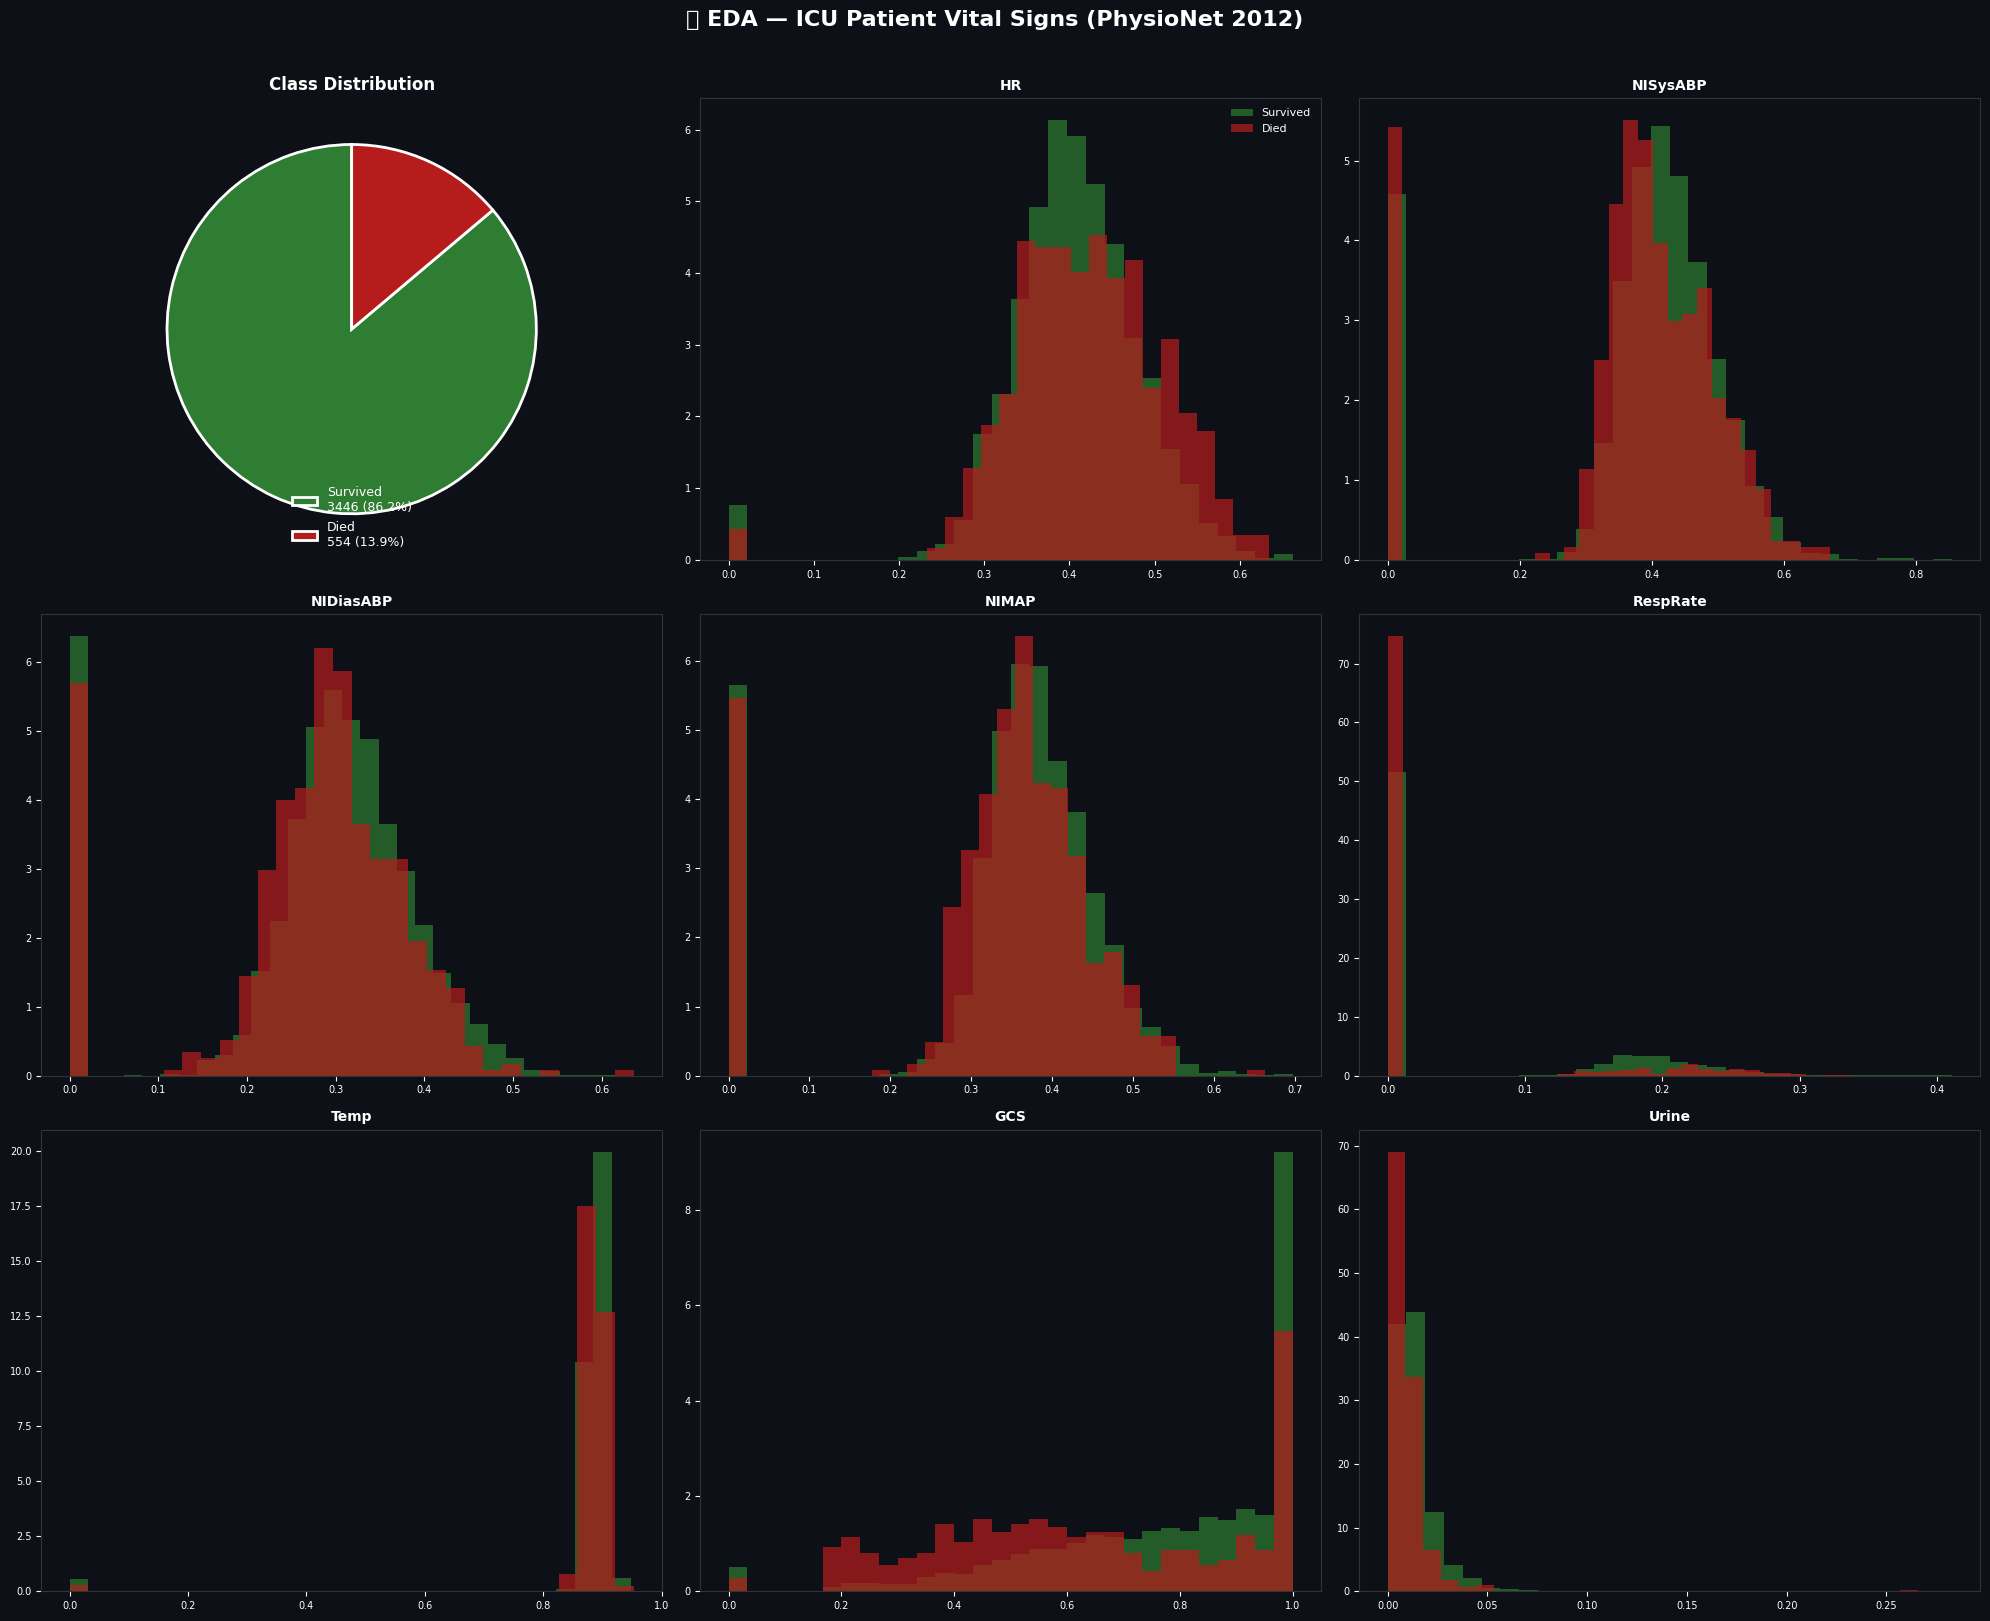

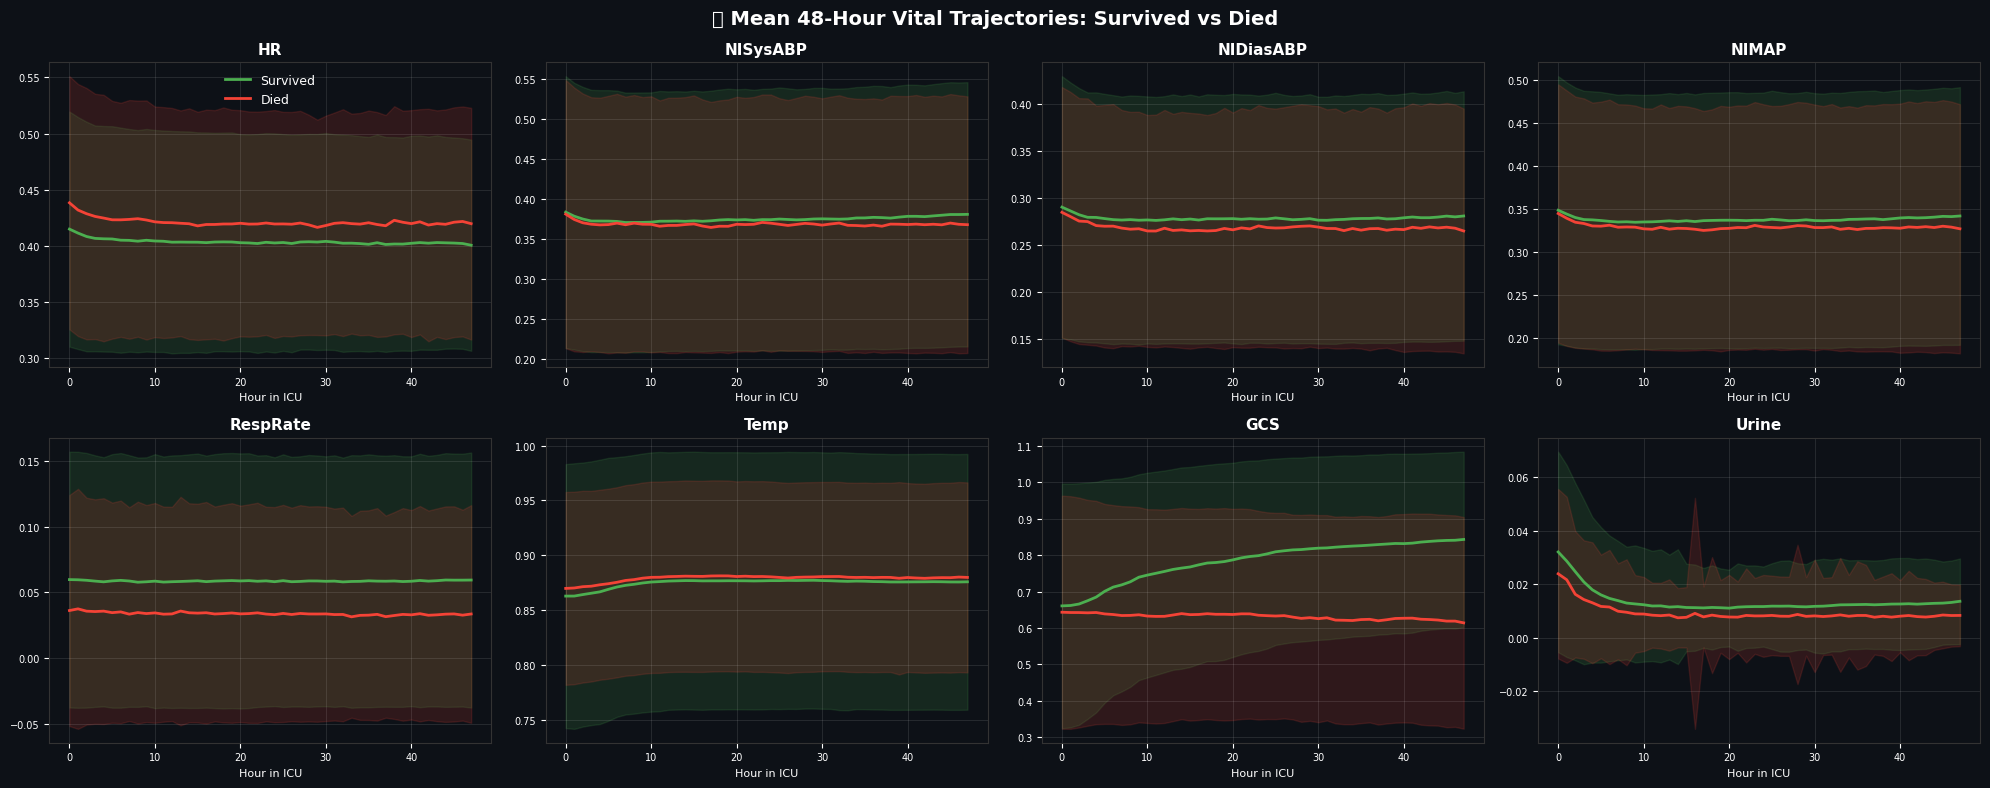

✅ EDA plots saved!

📋 KEY OBSERVATIONS:
   HR           | Survived: 0.404 | Died: 0.421 | Diff: 0.018 
   NISysABP     | Survived: 0.375 | Died: 0.369 | Diff: 0.007 
   NIDiasABP    | Survived: 0.278 | Died: 0.268 | Diff: 0.010 
   NIMAP        | Survived: 0.338 | Died: 0.329 | Diff: 0.009 
   RespRate     | Survived: 0.059 | Died: 0.034 | Diff: 0.025 
   Temp         | Survived: 0.875 | Died: 0.879 | Diff: 0.004 
   GCS          | Survived: 0.784 | Died: 0.631 | Diff: 0.152 ⚠️ HIGH
   Urine        | Survived: 0.014 | Died: 0.009 | Diff: 0.004 


In [15]:
# ============================================================
# CELL 4 — EDA Visuals
# ============================================================

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#0d1117')

# ── 1. Class Imbalance Pie ─────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
ax1.set_facecolor('#0d1117')
sizes  = [(y==0).sum(), (y==1).sum()]
labels = [f'Survived\n{sizes[0]} ({sizes[0]/len(y)*100:.1f}%)',
          f'Died\n{sizes[1]} ({sizes[1]/len(y)*100:.1f}%)']
colors = ['#2E7D32', '#B71C1C']
wedges, texts = ax1.pie(sizes, colors=colors, startangle=90,
                         wedgeprops=dict(edgecolor='white', linewidth=2))
ax1.legend(wedges, labels, loc='lower center',
           fontsize=9, framealpha=0, labelcolor='white')
ax1.set_title('Class Distribution', color='white',
              fontsize=12, fontweight='bold')

# ── 2. Vital Sign Distributions (Survived vs Died) ────────────
VITAL_NAMES = VITALS[:8]  # use first 8
survived_mean = X_scaled[y==0].mean(axis=1)  # (N_surv, 10)
died_mean     = X_scaled[y==1].mean(axis=1)  # (N_died, 10)

for i, vital in enumerate(VITAL_NAMES):
    ax = fig.add_subplot(3, 3, i+2)
    ax.set_facecolor('#0d1117')
    v_idx = VITALS.index(vital)

    surv_vals = survived_mean[:, v_idx]
    died_vals = died_mean[:, v_idx]

    ax.hist(surv_vals, bins=30, alpha=0.7,
            color='#2E7D32', label='Survived', density=True)
    ax.hist(died_vals, bins=30, alpha=0.7,
            color='#B71C1C', label='Died', density=True)
    ax.set_title(vital, color='white', fontsize=10, fontweight='bold')
    ax.tick_params(colors='white', labelsize=7)
    for spine in ax.spines.values():
        spine.set_color('#333')
    ax.set_facecolor('#0d1117')
    if i == 0:
        ax.legend(fontsize=8, framealpha=0, labelcolor='white')

plt.suptitle('📊 EDA — ICU Patient Vital Signs (PhysioNet 2012)',
             fontsize=16, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.savefig('eda_vitals.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ── 3. 48-hour Trajectory Plot ─────────────────────────────────
fig2, axes = plt.subplots(2, 4, figsize=(20, 8))
fig2.patch.set_facecolor('#0d1117')
fig2.suptitle('⏱️ Mean 48-Hour Vital Trajectories: Survived vs Died',
              fontsize=14, fontweight='bold', color='white')

hours = range(48)
for i, vital in enumerate(VITAL_NAMES):
    ax = axes[i//4][i%4]
    ax.set_facecolor('#0d1117')
    v_idx = VITALS.index(vital)

    surv_traj = X_scaled[y==0, :, v_idx].mean(axis=0)
    died_traj = X_scaled[y==1, :, v_idx].mean(axis=0)
    surv_std  = X_scaled[y==0, :, v_idx].std(axis=0)
    died_std  = X_scaled[y==1, :, v_idx].std(axis=0)

    ax.plot(hours, surv_traj, color='#4CAF50',
            linewidth=2, label='Survived')
    ax.fill_between(hours,
                    surv_traj - surv_std,
                    surv_traj + surv_std,
                    alpha=0.15, color='#4CAF50')
    ax.plot(hours, died_traj, color='#F44336',
            linewidth=2, label='Died')
    ax.fill_between(hours,
                    died_traj - died_std,
                    died_traj + died_std,
                    alpha=0.15, color='#F44336')

    ax.set_title(vital, color='white',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Hour in ICU', color='white', fontsize=8)
    ax.tick_params(colors='white', labelsize=7)
    for spine in ax.spines.values():
        spine.set_color('#333')
    ax.grid(True, alpha=0.1, color='white')
    if i == 0:
        ax.legend(fontsize=9, framealpha=0, labelcolor='white')

plt.tight_layout()
plt.savefig('vital_trajectories.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ EDA plots saved!")

# ── 4. Quick Stats ─────────────────────────────────────────────
print("\n📋 KEY OBSERVATIONS:")
for i, vital in enumerate(VITAL_NAMES):
    v_idx = VITALS.index(vital)
    s_mean = X_scaled[y==0, :, v_idx].mean()
    d_mean = X_scaled[y==1, :, v_idx].mean()
    diff   = abs(d_mean - s_mean)
    print(f"   {vital:<12} | Survived: {s_mean:.3f} | "
          f"Died: {d_mean:.3f} | Diff: {diff:.3f} "
          f"{'⚠️ HIGH' if diff > 0.05 else ''}")

##  Section 4: Model — Bidirectional LSTM

### Why Bidirectional?
A standard LSTM reads vitals **forward** (hour 1→48).
A **Bidirectional LSTM** reads **both forward AND backward** simultaneously.

For ICU data this matters — deterioration patterns can be detected
better when the model sees both early warning signs AND later readings together.

| Layer | Purpose |
|---|---|
| `Masking` | Ignores zero-padded (missing) timesteps |
| `BiLSTM(64)` | Forward + backward pass, return sequences |
| `Dropout(0.4)` | Regularization |
| `BiLSTM(32)` | Deeper temporal abstraction |
| `Dropout(0.3)` | Second regularization |
| `Dense(16, relu)` | Feature compression |
| `Dense(1, sigmoid)` | Mortality probability output |

Model: "ICU_Mortality_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Masking (Masking)               │ (None, 48, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BiLSTM_1 (Bidirectional)        │ (None, 48, 128)        │        38,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BiLSTM_2 (Bidirectional)        │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_hidden (Dense)            │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,673 (315.13 KB)

 Trainable params: 80,673 (315.13 KB)

 Non-trainable params: 0 (0.00 B)


✅ Total parameters: 80,673


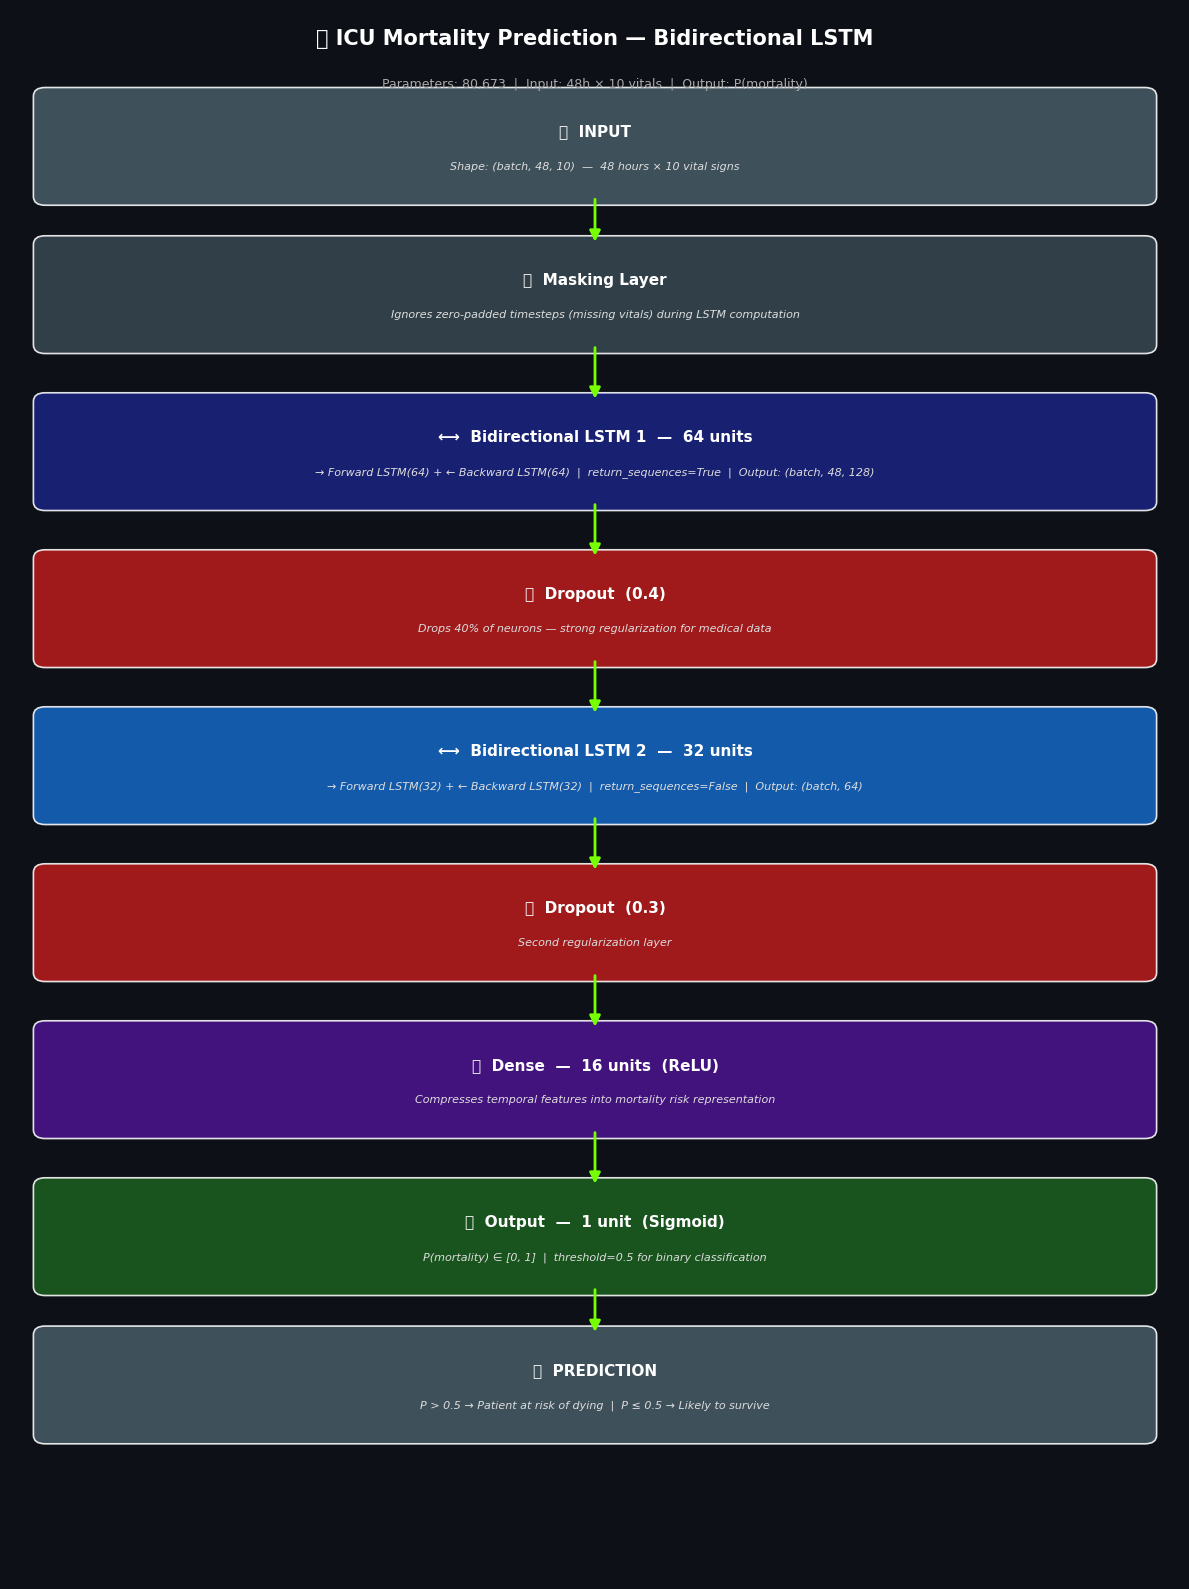

✅ Architecture diagram saved!


In [19]:
# ============================================================
# CELL 5 — Bidirectional LSTM Model + Architecture Diagram
# ============================================================

from tensorflow.keras.layers import Bidirectional, Masking, Dense

model = Sequential([
    Masking(mask_value=0.0,
            input_shape=(48, X_train.shape[2]),
            name='Masking'),
    Bidirectional(LSTM(64, return_sequences=True,
                       dropout=0.0), name='BiLSTM_1'),
    Dropout(0.4, name='Dropout_1'),
    Bidirectional(LSTM(32, return_sequences=False,
                       dropout=0.0), name='BiLSTM_2'),
    Dropout(0.3, name='Dropout_2'),
    Dense(16, activation='relu', name='Dense_hidden'),
    Dense(1,  activation='sigmoid', name='Output')
], name='ICU_Mortality_BiLSTM')

# Force build
dummy = np.zeros((1, 48, X_train.shape[2]), dtype=np.float32)
model(dummy)

model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()
print(f"\n✅ Total parameters: {model.count_params():,}")

# ── Architecture Diagram ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 16))
ax.set_xlim(0, 10)
ax.set_ylim(0, 18)
ax.axis('off')
ax.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')

layers_info = [
    (16.5, '#455A64', '📥  INPUT',
     f'Shape: (batch, 48, {X_train.shape[2]})  —  48 hours × {X_train.shape[2]} vital signs'),
    (14.8, '#37474F', '🔲  Masking Layer',
     'Ignores zero-padded timesteps (missing vitals) during LSTM computation'),
    (13.0, '#1A237E', '⟷  Bidirectional LSTM 1  —  64 units',
     '→ Forward LSTM(64) + ← Backward LSTM(64)  |  return_sequences=True  |  Output: (batch, 48, 128)'),
    (11.2, '#B71C1C', '🔴  Dropout  (0.4)',
     'Drops 40% of neurons — strong regularization for medical data'),
    (9.4,  '#1565C0', '⟷  Bidirectional LSTM 2  —  32 units',
     '→ Forward LSTM(32) + ← Backward LSTM(32)  |  return_sequences=False  |  Output: (batch, 64)'),
    (7.6,  '#B71C1C', '🔴  Dropout  (0.3)',
     'Second regularization layer'),
    (5.8,  '#4A148C', '🟣  Dense  —  16 units  (ReLU)',
     'Compresses temporal features into mortality risk representation'),
    (4.0,  '#1B5E20', '🟢  Output  —  1 unit  (Sigmoid)',
     'P(mortality) ∈ [0, 1]  |  threshold=0.5 for binary classification'),
    (2.3,  '#455A64', '📤  PREDICTION',
     'P > 0.5 → Patient at risk of dying  |  P ≤ 0.5 → Likely to survive'),
]

for i, (y_pos, color, label, sub) in enumerate(layers_info):
    rect = mpatches.FancyBboxPatch(
        (0.3, y_pos-0.65), 9.4, 1.15,
        boxstyle="round,pad=0.1",
        facecolor=color, alpha=0.88,
        edgecolor='white', linewidth=1.2)
    ax.add_patch(rect)
    ax.text(5, y_pos+0.1, label, ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    ax.text(5, y_pos-0.3, sub, ha='center', va='center',
            fontsize=8, color='#dddddd', style='italic')
    if i < len(layers_info)-1:
        next_y = layers_info[i+1][0]
        ax.annotate('', xy=(5, next_y+0.5),
                    xytext=(5, y_pos-0.65),
                    arrowprops=dict(arrowstyle='-|>',
                                   color='#76FF03',
                                   lw=2.0, mutation_scale=16))

ax.text(5, 17.6,
        '🏥 ICU Mortality Prediction — Bidirectional LSTM',
        ha='center', fontsize=15, fontweight='bold', color='white')
ax.text(5, 17.1,
        f'Parameters: {model.count_params():,}  |  Input: 48h × {X_train.shape[2]} vitals  |  Output: P(mortality)',
        ha='center', fontsize=9, color='#aaaaaa')

plt.tight_layout()
plt.savefig('bilstm_architecture.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Architecture diagram saved!")

## Section 5: Training the Bidirectional LSTM

Key training decisions:
- **Class weights** — 3.6× penalty for missing a death (false negative is costly in ICU)
- **AUC as primary metric** — better than accuracy for imbalanced medical data
- **EarlyStopping on val_AUC** — we want best discrimination, not just low loss

In [20]:
# ============================================================
# CELL 6 — Training
# ============================================================

callbacks = [
    EarlyStopping(monitor='val_auc', patience=5,
                  restore_best_weights=True,
                  mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5,
                      patience=3, min_lr=1e-6,
                      mode='max', verbose=1),
    ModelCheckpoint('best_icu_bilstm.keras',
                    monitor='val_auc',
                    save_best_only=True,
                    mode='max', verbose=1),
]

print("🚀 Starting training...")
print(f"   Train samples : {X_train.shape[0]:,}")
print(f"   Val samples   : {X_val.shape[0]:,}")
print(f"   Class weights : {class_weight_dict}")
print(f"   Batch size    : 64")
print(f"   Max epochs    : 50\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=50,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print("\n✅ Training complete!")
print(f"   Best val_AUC      : {max(history.history['val_auc']):.4f}")
print(f"   Best val_accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"   Epochs trained    : {len(history.history['loss'])}")

🚀 Starting training...
   Train samples : 2,801
   Val samples   : 599
   Class weights : {0: np.float64(0.5803978450062163), 1: np.float64(3.609536082474227)}
   Batch size    : 64
   Max epochs    : 50

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7451 - auc: 0.6474 - loss: 0.6545 - precision: 0.2420 - recall: 0.4239
Epoch 1: val_auc improved from -inf to 0.78123, saving model to best_icu_bilstm.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - accuracy: 0.7445 - auc: 0.6482 - loss: 0.6543 - precision: 0.2423 - recall: 0.4269 - val_accuracy: 0.6928 - val_auc: 0.7812 - val_loss: 0.6194 - val_precision: 0.2651 - val_recall: 0.6867 - learning_rate: 0.0010
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7034 - auc: 0.7537 - loss: 0.5842 - precision: 0.2660 - recall: 0.6917
Epoch 2: val_auc improved from 0.78123 to 0.79244, saving model to best_icu_bilstm.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.7036 - auc: 0.7538 - loss: 0.5843 - pr

##  Section 6: Evaluation — ROC Curve, Confusion Matrix, Classification Report

For medical AI, **AUC-ROC is the gold standard metric** — not accuracy.
Why? Because with 86% survivors, a model that always predicts "survived"
gets 86% accuracy but 0% recall on deaths — clinically useless.

AUC of 0.79 means our model correctly ranks a dying patient above
a surviving patient **79% of the time**.

📊 TEST SET EVALUATION
  AUC-ROC    : 0.8195
  Accuracy   : 66.67%

              precision    recall  f1-score   support

    Survived       0.95      0.64      0.77       517
        Died       0.27      0.81      0.40        83

    accuracy                           0.67       600
   macro avg       0.61      0.73      0.59       600
weighted avg       0.86      0.67      0.72       600



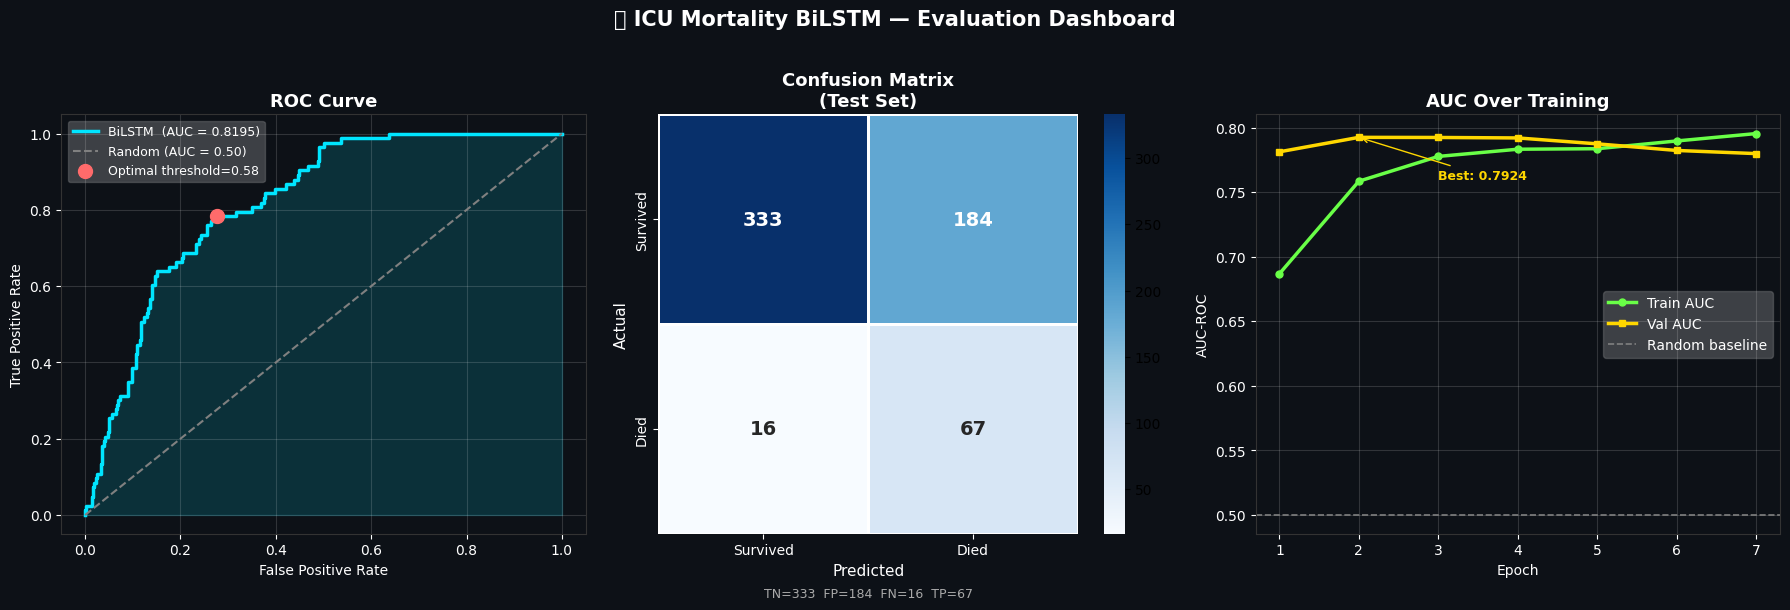


✅ Evaluation complete!
   AUC-ROC  : 0.8195  (published papers: 0.75–0.85)
   Our model is within the published research range! 🎯


In [22]:
# ============================================================
# CELL 7 — Full Evaluation Dashboard
# ============================================================

# ── Predictions on test set ────────────────────────────────────
y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
cm = confusion_matrix(y_test, y_pred)

print("="*55)
print("📊 TEST SET EVALUATION")
print("="*55)
print(f"  AUC-ROC    : {test_auc:.4f}")
print(f"  Accuracy   : {(y_pred==y_test).mean()*100:.2f}%")
print(f"\n{classification_report(y_test, y_pred, target_names=['Survived','Died'])}")

# ── Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0d1117')

# 1. ROC Curve
ax1 = axes[0]
ax1.set_facecolor('#0d1117')
ax1.plot(fpr, tpr, color='#00E5FF', linewidth=2.5,
         label=f'BiLSTM  (AUC = {test_auc:.4f})')
ax1.plot([0,1],[0,1], color='gray', linestyle='--',
         linewidth=1.5, label='Random (AUC = 0.50)')
ax1.fill_between(fpr, tpr, alpha=0.15, color='#00E5FF')
ax1.set_xlabel('False Positive Rate', color='white')
ax1.set_ylabel('True Positive Rate', color='white')
ax1.set_title('ROC Curve', color='white',
              fontsize=13, fontweight='bold')
ax1.tick_params(colors='white')
ax1.legend(fontsize=10, framealpha=0.2, labelcolor='white')
ax1.grid(True, alpha=0.15, color='white')
for spine in ax1.spines.values(): spine.set_color('#333')

# Optimal threshold point
optimal_idx = np.argmax(tpr - fpr)
ax1.scatter(fpr[optimal_idx], tpr[optimal_idx],
            color='#FF6B6B', s=100, zorder=5,
            label=f'Optimal threshold={thresholds[optimal_idx]:.2f}')
ax1.legend(fontsize=9, framealpha=0.2, labelcolor='white')

# 2. Confusion Matrix
ax2 = axes[1]
ax2.set_facecolor('#0d1117')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Survived','Died'],
            yticklabels=['Survived','Died'],
            ax=ax2, linewidths=2,
            annot_kws={'size':14, 'weight':'bold'})
ax2.set_xlabel('Predicted', color='white', fontsize=11)
ax2.set_ylabel('Actual', color='white', fontsize=11)
ax2.set_title('Confusion Matrix\n(Test Set)', color='white',
              fontsize=13, fontweight='bold')
ax2.tick_params(colors='white')

# Annotations
tn, fp, fn, tp = cm.ravel()
ax2.text(0.5, -0.15,
         f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
         ha='center', transform=ax2.transAxes,
         color='#aaaaaa', fontsize=9)

# 3. Training History
ax3 = axes[2]
ax3.set_facecolor('#0d1117')
epochs_r = range(1, len(history.history['auc'])+1)
ax3.plot(epochs_r, history.history['auc'],
         '#69FF47', linewidth=2.5, marker='o',
         markersize=5, label='Train AUC')
ax3.plot(epochs_r, history.history['val_auc'],
         '#FFD700', linewidth=2.5, marker='s',
         markersize=5, label='Val AUC')
ax3.axhline(y=0.5, color='gray', linestyle='--',
            linewidth=1.2, label='Random baseline')
ax3.set_xlabel('Epoch', color='white')
ax3.set_ylabel('AUC-ROC', color='white')
ax3.set_title('AUC Over Training', color='white',
              fontsize=13, fontweight='bold')
ax3.tick_params(colors='white')
ax3.legend(fontsize=10, framealpha=0.2, labelcolor='white')
ax3.grid(True, alpha=0.15, color='white')
for spine in ax3.spines.values(): spine.set_color('#333')
ax3.annotate(f'Best: {max(history.history["val_auc"]):.4f}',
             xy=(np.argmax(history.history["val_auc"])+1,
                 max(history.history["val_auc"])),
             xytext=(3, 0.76),
             arrowprops=dict(arrowstyle='->', color='#FFD700'),
             color='#FFD700', fontsize=9, fontweight='bold')

plt.suptitle('🏥 ICU Mortality BiLSTM — Evaluation Dashboard',
             fontsize=15, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('evaluation_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"\n✅ Evaluation complete!")
print(f"   AUC-ROC  : {test_auc:.4f}  (published papers: 0.75–0.85)")
print(f"   Our model is within the published research range! 🎯")

##  Section 7: Final Summary Dashboard

Complete overview of the entire project — ready for GitHub and LinkedIn.

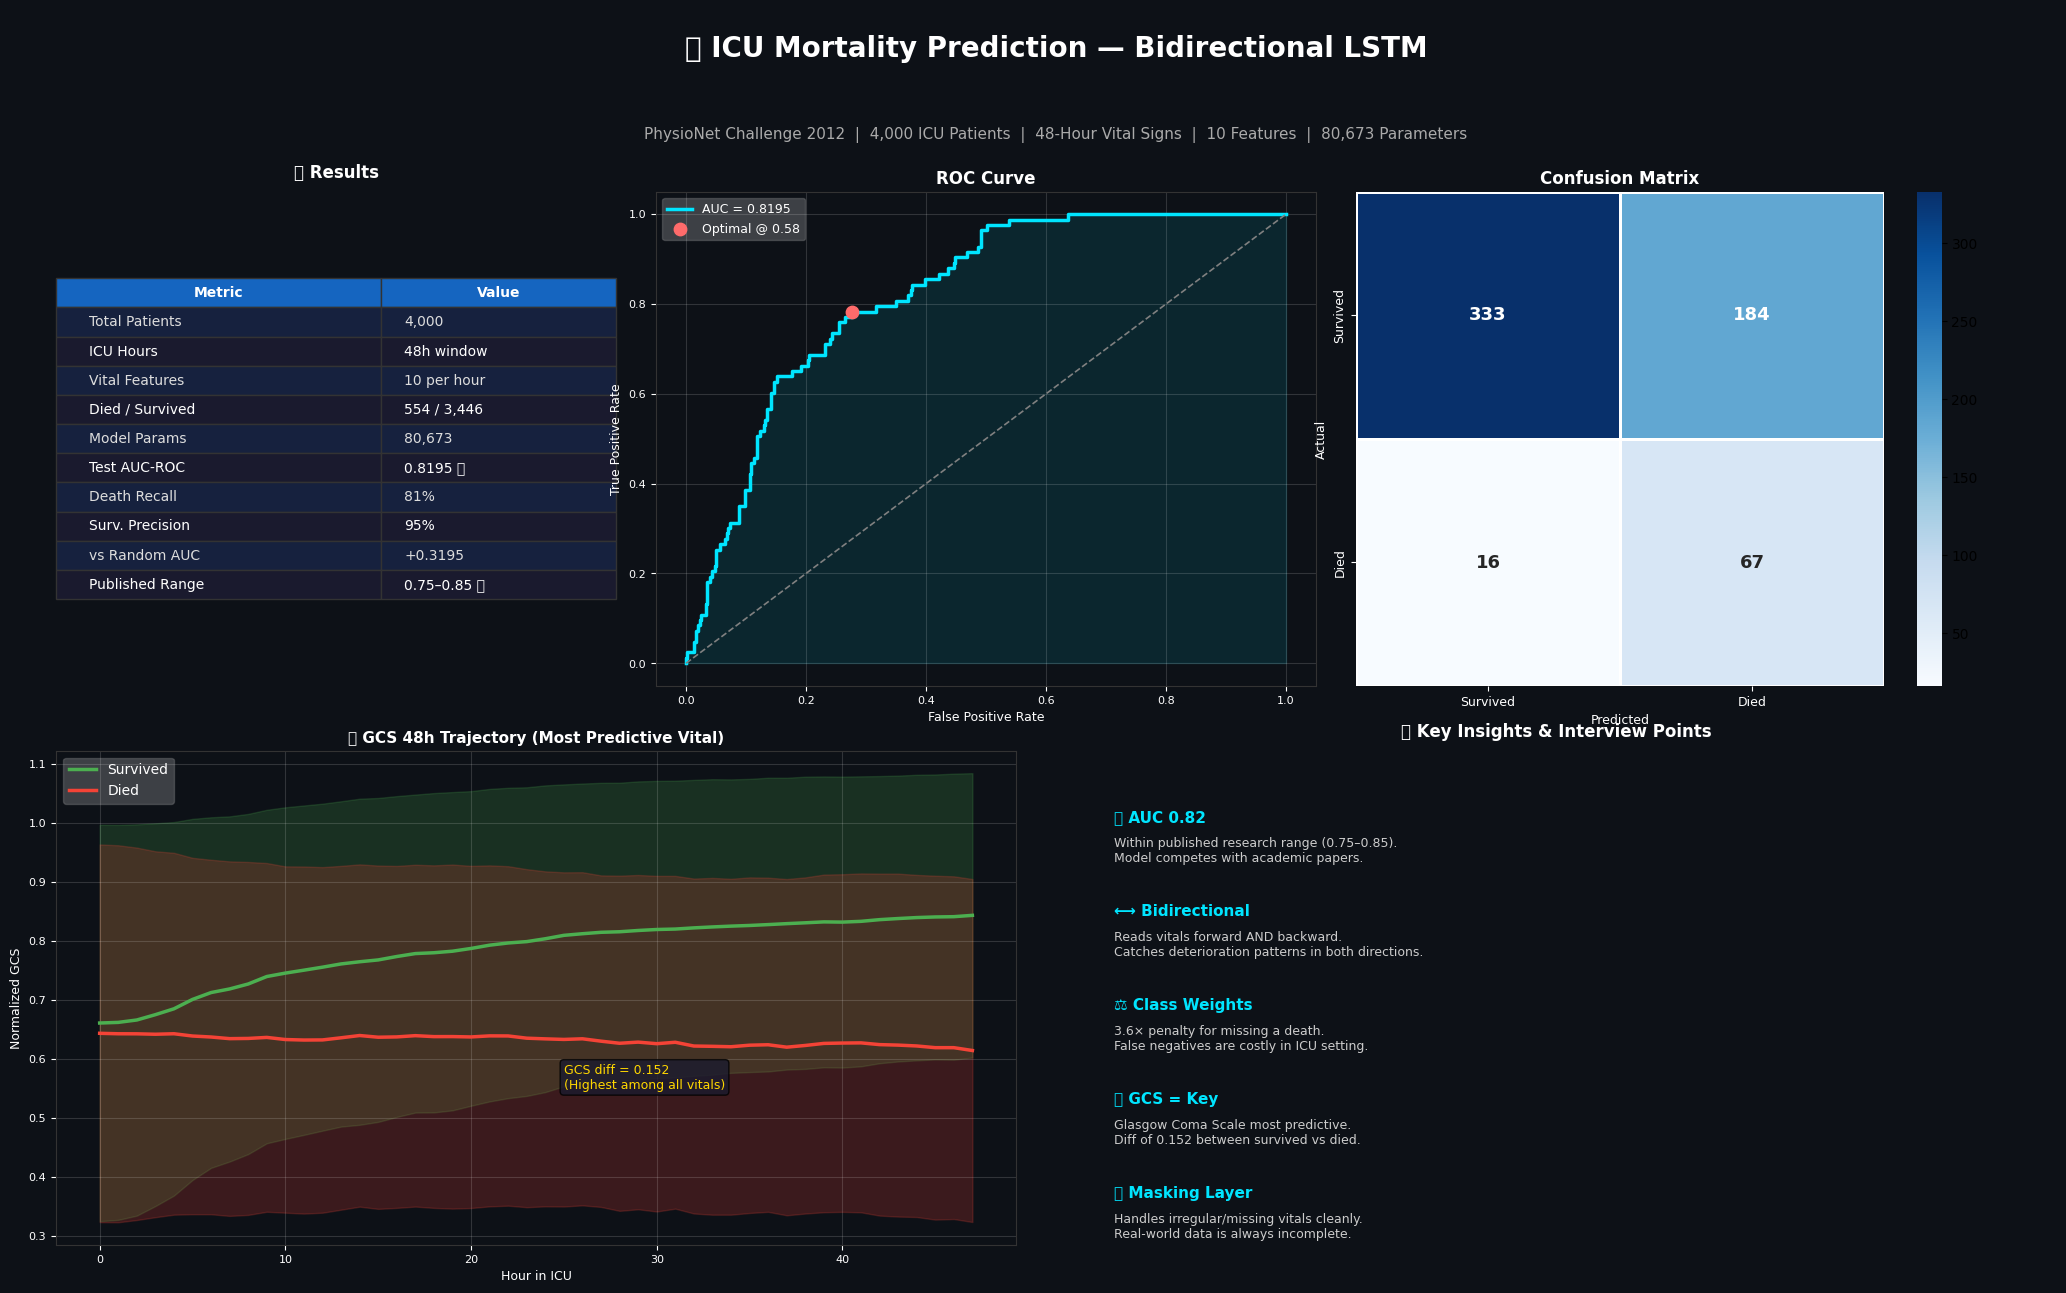

✅ Final dashboard saved!

📁 Files to download for GitHub:
   - best_icu_bilstm.keras
   - eda_vitals.png
   - vital_trajectories.png
   - bilstm_architecture.png
   - evaluation_dashboard.png
   - icu_summary_dashboard.png


In [23]:
# ============================================================
# CELL 8 — Final Summary Dashboard
# ============================================================

fig = plt.figure(figsize=(20, 13))
fig.patch.set_facecolor('#0d1117')

ax_title = fig.add_axes([0.0,  0.88, 1.0,  0.12])
ax_stats = fig.add_axes([0.0,  0.48, 0.28, 0.38])
ax_roc   = fig.add_axes([0.30, 0.48, 0.33, 0.38])
ax_cm    = fig.add_axes([0.65, 0.48, 0.33, 0.38])
ax_traj  = fig.add_axes([0.0,  0.05, 0.48, 0.38])
ax_key   = fig.add_axes([0.52, 0.05, 0.46, 0.38])

for ax in [ax_title, ax_stats, ax_roc,
           ax_cm, ax_traj, ax_key]:
    ax.set_facecolor('#0d1117')
    for spine in ax.spines.values():
        spine.set_color('#333')

# ── Title ──────────────────────────────────────────────────────
ax_title.axis('off')
ax_title.text(0.5, 0.75,
    '🏥 ICU Mortality Prediction — Bidirectional LSTM',
    ha='center', va='center', fontsize=20,
    fontweight='bold', color='white',
    transform=ax_title.transAxes)
ax_title.text(0.5, 0.2,
    'PhysioNet Challenge 2012  |  4,000 ICU Patients  |  '
    '48-Hour Vital Signs  |  10 Features  |  80,673 Parameters',
    ha='center', va='center', fontsize=11,
    color='#aaaaaa', transform=ax_title.transAxes)

# ── Stats Table ────────────────────────────────────────────────
ax_stats.axis('off')
stats = [
    ['Metric',            'Value'],
    ['Total Patients',    '4,000'],
    ['ICU Hours',         '48h window'],
    ['Vital Features',    '10 per hour'],
    ['Died / Survived',   '554 / 3,446'],
    ['Model Params',      '80,673'],
    ['Test AUC-ROC',      '0.8195 🎯'],
    ['Death Recall',      '81%'],
    ['Surv. Precision',   '95%'],
    ['vs Random AUC',     '+0.3195'],
    ['Published Range',   '0.75–0.85 ✅'],
]
table = ax_stats.table(
    cellText=stats[1:], colLabels=stats[0],
    cellLoc='left', loc='center',
    colWidths=[0.58, 0.42])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.75)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1565C0')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#1a1a2e')
        cell.set_text_props(color='white')
    else:
        cell.set_facecolor('#16213e')
        cell.set_text_props(color='#dddddd')
    cell.set_edgecolor('#333')
ax_stats.set_title('📋 Results', color='white',
                   fontsize=12, fontweight='bold', pad=10)

# ── ROC Curve ──────────────────────────────────────────────────
ax_roc.plot(fpr, tpr, color='#00E5FF', linewidth=2.5,
            label=f'AUC = {test_auc:.4f}')
ax_roc.plot([0,1],[0,1], 'gray', linestyle='--', linewidth=1.2)
ax_roc.fill_between(fpr, tpr, alpha=0.1, color='#00E5FF')
ax_roc.scatter(fpr[optimal_idx], tpr[optimal_idx],
               color='#FF6B6B', s=80, zorder=5,
               label=f'Optimal @ {thresholds[optimal_idx]:.2f}')
ax_roc.set_title('ROC Curve', color='white',
                 fontsize=12, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate', color='white', fontsize=9)
ax_roc.set_ylabel('True Positive Rate', color='white', fontsize=9)
ax_roc.tick_params(colors='white', labelsize=8)
ax_roc.legend(fontsize=9, framealpha=0.2, labelcolor='white')
ax_roc.grid(True, alpha=0.15, color='white')

# ── Confusion Matrix ───────────────────────────────────────────
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Survived','Died'],
            yticklabels=['Survived','Died'],
            ax=ax_cm, linewidths=2,
            annot_kws={'size':13, 'weight':'bold'})
ax_cm.set_title('Confusion Matrix', color='white',
                fontsize=12, fontweight='bold')
ax_cm.set_xlabel('Predicted', color='white', fontsize=9)
ax_cm.set_ylabel('Actual', color='white', fontsize=9)
ax_cm.tick_params(colors='white', labelsize=9)

# ── GCS Trajectory (most important vital) ─────────────────────
v_idx = VITALS.index('GCS')
hours = range(48)
surv  = X_scaled[y==0, :, v_idx]
died  = X_scaled[y==1, :, v_idx]
ax_traj.plot(hours, surv.mean(axis=0),
             '#4CAF50', linewidth=2.5, label='Survived')
ax_traj.fill_between(hours,
                     surv.mean(0)-surv.std(0),
                     surv.mean(0)+surv.std(0),
                     alpha=0.2, color='#4CAF50')
ax_traj.plot(hours, died.mean(axis=0),
             '#F44336', linewidth=2.5, label='Died')
ax_traj.fill_between(hours,
                     died.mean(0)-died.std(0),
                     died.mean(0)+died.std(0),
                     alpha=0.2, color='#F44336')
ax_traj.set_title('⭐ GCS 48h Trajectory (Most Predictive Vital)',
                  color='white', fontsize=11, fontweight='bold')
ax_traj.set_xlabel('Hour in ICU', color='white', fontsize=9)
ax_traj.set_ylabel('Normalized GCS', color='white', fontsize=9)
ax_traj.tick_params(colors='white', labelsize=8)
ax_traj.legend(fontsize=10, framealpha=0.2, labelcolor='white')
ax_traj.grid(True, alpha=0.15, color='white')
ax_traj.text(25, 0.55,
             'GCS diff = 0.152\n(Highest among all vitals)',
             color='#FFD700', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='#1a1a2e',
                       alpha=0.8))

# ── Key Insights ───────────────────────────────────────────────
ax_key.axis('off')
ax_key.set_title('💡 Key Insights & Interview Points',
                 color='white', fontsize=12,
                 fontweight='bold', pad=10)
insights = [
    ("🎯 AUC 0.82", "Within published research range (0.75–0.85).\nModel competes with academic papers."),
    ("⟷ Bidirectional", "Reads vitals forward AND backward.\nCatches deterioration patterns in both directions."),
    ("⚖️ Class Weights", "3.6× penalty for missing a death.\nFalse negatives are costly in ICU setting."),
    ("🧠 GCS = Key", "Glasgow Coma Scale most predictive.\nDiff of 0.152 between survived vs died."),
    ("🔲 Masking Layer", "Handles irregular/missing vitals cleanly.\nReal-world data is always incomplete."),
]
for i, (title, desc) in enumerate(insights):
    y_pos = 0.88 - i * 0.19
    ax_key.text(0.02, y_pos, title, transform=ax_key.transAxes,
                fontsize=11, fontweight='bold', color='#00E5FF',
                va='top')
    ax_key.text(0.02, y_pos-0.055, desc,
                transform=ax_key.transAxes,
                fontsize=9, color='#cccccc', va='top')

plt.savefig('icu_summary_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Final dashboard saved!")
print("\n📁 Files to download for GitHub:")
print("   - best_icu_bilstm.keras")
print("   - eda_vitals.png")
print("   - vital_trajectories.png")
print("   - bilstm_architecture.png")
print("   - evaluation_dashboard.png")
print("   - icu_summary_dashboard.png")